# Valoración y segmentación del mercado de vivienda en Colombia

**Grupo 6 · Business Analytics & Big Data II (ING-SOF8-N) · Docente: Oscar Castiblanco**

Maria Alejandra Toro Ortiz · Mario Alejandro Peña Arenas · Javier Alexander Moreno Avila · Kevin Steven Guzmán Acevedo

---

## Qué es este notebook

Es **todo el proyecto en un solo archivo**: parte del dataset original, revisa su calidad, lo limpia,
lo explora, entrena los modelos y exporta los resultados. No depende de ningún otro código.

**Todas las cifras de la presentación salen de aquí.** Al final, el notebook guarda un resumen en
`salida/resumen.json`, un CSV para Power BI y las figuras.

## Cómo está organizado

Las secciones siguen el mismo orden que las diapositivas:

| Sección | Qué responde | Diapositiva |
|---|---|---|
| 1. Preparación | Entorno, estilo y ubicación de los datos | — |
| 2. Dataset | ¿De dónde salen los datos y cómo son? | 3 |
| 3. Variables | ¿Qué significa cada columna y para qué la usamos? | 4 |
| 4. Data Quality | ¿Qué problemas tienen los datos? | 5 |
| 5. Data Cleaning | ¿Qué hicimos para corregirlos y por qué? | 6 |
| 6. Exploración | ¿Qué nos dicen los datos? | 7 |
| 7. Machine Learning supervisado | ¿Cuánto vale una vivienda? | 8-9 |
| 8. Machine Learning no supervisado | ¿Qué grupos de vivienda existen? | 8-9 |
| 9. Resultados | ¿Qué aprendimos y qué decisión habilita? | 9 |
| 10. Limitaciones | ¿Qué no pudimos resolver? | 10 |
| 11. Exportar | Resultados para la presentación y para Power BI | — |

## Cómo ejecutarlo

- **En Google Colab:** *Entorno de ejecución → Ejecutar todas*. Descarga el dataset por sí solo.
- **En local (VS Code):** abrir esta carpeta, elegir el kernel de Python y *Run All*.
- Tarda unos 2 o 3 minutos, casi todo en leer los 618 MB del archivo.

## Cómo leer cada celda

Cada celda de código va precedida de un recuadro con tres líneas:

> **Qué hace** · lo que ejecuta la celda
> **Por qué** · la razón de hacerlo
> **Qué observar** · lo que hay que mirar en el resultado

---
# 1. Preparación

> **Qué hace:** importa las librerías, define los colores y las funciones de apoyo, y crea la carpeta
> `salida/` donde se guardarán figuras y resultados.
> **Por qué:** un único estilo visual hace que todas las gráficas se lean igual. El diccionario `R` va
> guardando cada cifra importante para exportarla al final.
> **Qué observar:** solo debe imprimir las versiones de las librerías. Si falla algún `import`, hay que
> instalar la librería (`pip install pandas scikit-learn matplotlib`).

In [1]:
import json, re, urllib.request, warnings, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 70)

# --- Estilo visual único para todas las figuras ---
AZUL, NARANJA, VERDE, ROJO, MORADO = "#2a78d6", "#eb6834", "#1baf7a", "#c0392b", "#7b5ea7"
TINTA, SUAVE, REJILLA = "#0b0b0b", "#52514e", "#e5e5e2"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c9c9c4",
    "axes.labelcolor": SUAVE, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.titlecolor": TINTA, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8, "xtick.color": SUAVE,
    "ytick.color": SUAVE, "font.size": 11, "figure.dpi": 110,
})

SALIDA = Path("salida")
FIGURAS = SALIDA / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

R = {}   # resumen: aquí se guardan las cifras que usará la presentación


def limpiar(ax):
    """Quita los bordes superior y derecho: menos tinta, más datos."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


def guardar(fig, nombre):
    """Guarda la figura en salida/figuras/ para usarla en la presentación."""
    fig.savefig(FIGURAS / f"{nombre}.png", dpi=150, bbox_inches="tight")


print(f"pandas {pd.__version__} · numpy {np.__version__} · scikit-learn {sklearn.__version__}")

pandas 3.0.3 · numpy 2.5.0 · scikit-learn 1.9.0


> **Qué hace:** busca el archivo `co_properties.csv`; si no está, lo descarga de Kaggle (146 MB comprimido).
> **Por qué:** así el notebook funciona igual en el computador del proyecto que en Google Colab, sin
> pasos manuales. La descarga pública de Kaggle no exige cuenta.
> **Qué observar:** el tamaño de cada archivo. `co_properties.csv` debe pesar unos 618 MB.
> Si la descarga falla en Colab, subir el archivo a la carpeta `datos/` con el panel de la izquierda.

In [2]:
FUENTES = {
    "co_properties.csv": "julianusugaortiz/colombia-housing-properties-price",   # dataset principal
    "medellin_properties.csv": "cesaregr/medelln-properties",                     # dataset de apoyo
}
CANDIDATAS = [Path("datos"), Path("proyecto_vivienda/datos"), Path(".")]
DATOS = next((c for c in CANDIDATAS if (c / "co_properties.csv").exists()), Path("datos"))
DATOS.mkdir(exist_ok=True)

for archivo, slug in FUENTES.items():
    ruta = DATOS / archivo
    if not ruta.exists():
        print(f"Descargando {archivo} desde Kaggle...")
        zip_tmp = DATOS / f"{archivo}.zip"
        urllib.request.urlretrieve(f"https://www.kaggle.com/api/v1/datasets/download/{slug}", zip_tmp)
        with zipfile.ZipFile(zip_tmp) as z:
            z.extractall(DATOS)
        zip_tmp.unlink()
    print(f"{archivo:<26}{ruta.stat().st_size / 1e6:>9,.1f} MB   ->  {ruta}")

co_properties.csv             617.7 MB   ->  datos\co_properties.csv
medellin_properties.csv         0.8 MB   ->  datos\medellin_properties.csv


---
# 2. Dataset

**Colombia Housing Properties Price** — avisos del portal inmobiliario Properati, publicados en Kaggle.

| | |
|---|---|
| **Fuente** | Kaggle, publicado por `julianusugaortiz` (los datos provienen de Properati) |
| **Enlace** | https://www.kaggle.com/datasets/julianusugaortiz/colombia-housing-properties-price |
| **Formato** | CSV |
| **Licencia** | «Unknown» en Kaggle: se usa solo con fines académicos |

**¿Por qué este dataset?** De seis candidatos, es el único que reúne varias ciudades, precio, tipo de
inmueble y fechas de publicación y de baja. Los demás eran demasiado pequeños (Bogotá: 585 registros),
de otro país (Ames, Estados Unidos), medían otra cosa (valor del terreno en Catastro Bogotá) o no incluían
Colombia (el Properati oficial de Kaggle).

> **Qué hace:** lee el archivo completo y muestra cuántos registros y variables tiene, el periodo que cubre
> y las primeras filas.
> **Por qué:** antes de analizar hay que saber con qué se trabaja: tamaño, columnas y época de los datos.
> **Qué observar:** 1.000.000 de filas y 25 columnas. Cubre de julio de 2020 a agosto de 2021, así que
> **no refleja precios actuales**. Se omiten `title` y `description` en la vista por su extensión.

In [3]:
df = pd.read_csv(DATOS / "co_properties.csv", low_memory=False)

R["dataset"] = {
    "filas": len(df), "columnas": df.shape[1],
    "periodo": [df["start_date"].min(), df["start_date"].max()],
    "megabytes": round((DATOS / "co_properties.csv").stat().st_size / 1e6, 1),
}
print(f"Registros : {len(df):,}")
print(f"Variables : {df.shape[1]}")
print(f"Periodo   : {R['dataset']['periodo'][0]}  a  {R['dataset']['periodo'][1]}")
df.drop(columns=["title", "description"]).head(3)

Registros : 1,000,000
Variables : 25
Periodo   : 2020-07-26  a  2021-08-19


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type
0,KsjahK62rxcYKXXQjOdkqw==,Propiedad,2020-10-07,2021-10-09,2020-10-07,3.9210,-76.506000,Colombia,Valle del Cauca,NaN,NaN,NaN,NaN,NaN,6.0,7.0,NaN,NaN,1.300000e+09,COP,NaN,Casa,Venta
1,Y+gsBZYq1zu5NoR3V5oUGA==,Propiedad,2020-10-07,2021-01-06,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,COP,NaN,Casa,Venta
2,Jpzqxj8/Vgf3Aa5ASxUBNg==,Propiedad,2020-10-07,2020-10-07,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,COP,Mensual,Casa,Venta


### Dataset de apoyo: Medellín (2023)

> **Qué hace:** carga un segundo dataset, pequeño pero más completo.
> **Por qué:** en el dataset principal casi ningún aviso trae el área (lo veremos en Data Quality). El de
> Medellín la trae siempre, y sirve para **comprobar** que la relación entre área y precio que vemos en el
> principal es real y no un efecto de los datos faltantes.
> **Qué observar:** 9.999 registros y solo 12 columnas, pero con `area` y `stratum` (estrato) completos.

In [4]:
dm = pd.read_csv(DATOS / "medellin_properties.csv")
print(f"Registros: {len(dm):,}   Variables: {dm.shape[1]}   Columnas: {list(dm.columns)}")
print(f"Área sin dato: {dm['area'].isna().mean() * 100:.1f} %")
R["apoyo"] = {"filas": len(dm), "columnas": dm.shape[1]}

Registros: 9,999   Variables: 12   Columnas: ['neighbourhood', 'latitude', 'longitude', 'property_type', 'price', 'rooms', 'baths', 'area', 'administration_price', 'age', 'garages', 'stratum']
Área sin dato: 0.0 %


---
# 3. Variables

> **Qué hace:** lista las 25 columnas con su tipo, el porcentaje de datos que faltan y el papel que juega
> cada una en el proyecto.
> **Por qué:** entender cada variable evita usarla mal. Por ejemplo, `l4` parece el barrio pero en realidad
> es la *zona*; el barrio es `l6`.
> **Qué observar:** la columna `rol`. Solo una es la **variable objetivo** (`price`), y varias no se usan.

In [5]:
ROLES = {
    "id": "Identificador del aviso",
    "ad_type": "No se usa (constante)",
    "start_date": "Fecha de publicación", "end_date": "Fecha de baja (9999-12-31 = aviso vigente)",
    "created_on": "No se usa (repite start_date)",
    "lat": "Ubicación (coordenada)", "lon": "Ubicación (coordenada)",
    "l1": "País (filtro)", "l2": "Departamento", "l3": "Ciudad", "l4": "Zona de la ciudad",
    "l5": "No se usa (84 % vacía)", "l6": "No se usa (barrio, 95 % vacía)",
    "rooms": "Ambientes", "bedrooms": "Dormitorios (predictor)", "bathrooms": "Baños (predictor)",
    "surface_total": "Área total m² (predictor principal)", "surface_covered": "Área construida m²",
    "price": "VARIABLE OBJETIVO: precio publicado", "currency": "Moneda (filtro)",
    "price_period": "Periodicidad del precio (control de calidad)",
    "title": "Texto libre (se elimina: privacidad)", "description": "Texto libre (se elimina: privacidad)",
    "property_type": "Tipo de inmueble (predictor y filtro)", "operation_type": "Venta o arriendo (filtro)",
}
variables = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "% sin dato": (df.isna().mean() * 100).round(2),
    "rol": pd.Series(ROLES),
})
variables

,tipo,% sin dato,rol
id,str,0.00,Identificador del aviso
ad_type,str,0.00,No se usa (constante)
start_date,str,0.00,Fecha de publicación
end_date,str,0.00,Fecha de baja (9999-12-31 = aviso vigente)
created_on,str,0.00,No se usa (repite start_date)
lat,float64,25.97,Ubicación (coordenada)
lon,float64,25.97,Ubicación (coordenada)
l1,str,0.00,País (filtro)
l2,str,0.00,Departamento
l3,str,6.28,Ciudad


---
# 4. Data Quality

Antes de limpiar hay que **diagnosticar**. Revisamos siete tipos de problema: valores faltantes,
duplicados, tipos incorrectos, valores inconsistentes, valores atípicos, columnas innecesarias y
problemas de formato.

### 4.1 Valores faltantes

> **Qué hace:** calcula el porcentaje de avisos sin dato en cada columna y lo grafica.
> **Por qué:** los faltantes determinan qué variables se pueden usar y cuántos registros sobrevivirán.
> **Qué observar:** en naranja las columnas casi vacías. **El área (`surface_total`) falta en el 96 %
> de los avisos**: es el problema que condiciona todo el proyecto.

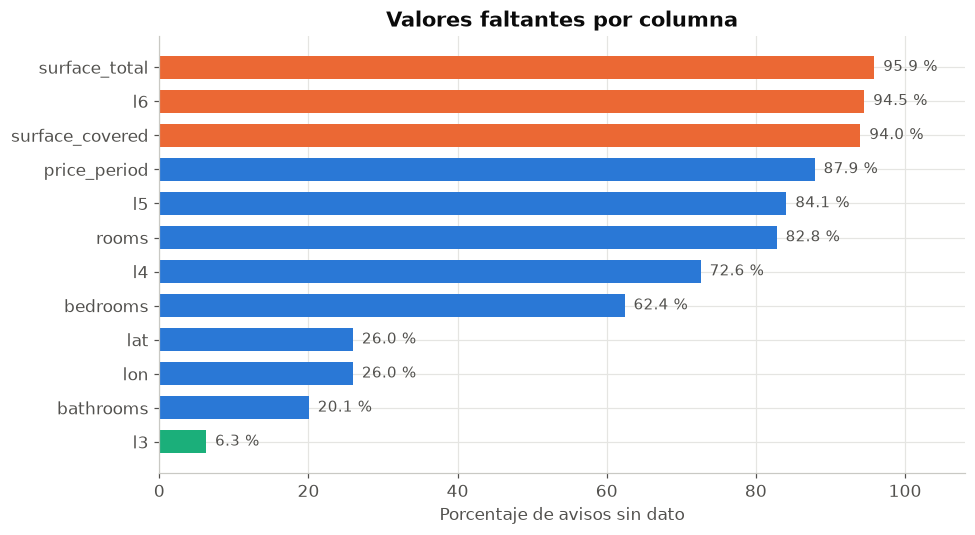

In [6]:
nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
R["calidad"] = {"nulos": nulos[nulos > 0].to_dict()}

top = nulos.head(12).sort_values()
colores = [NARANJA if v >= 90 else (AZUL if v >= 20 else VERDE) for v in top]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top.values, color=colores, height=0.68)
for y, v in enumerate(top.values):
    ax.text(v + 1.2, y, f"{v:.1f} %", va="center", fontsize=9.5, color=SUAVE)
ax.set_xlim(0, 108)
ax.set_xlabel("Porcentaje de avisos sin dato")
ax.set_title("Valores faltantes por columna")
limpiar(ax); plt.tight_layout()
guardar(fig, "calidad_nulos"); plt.show()

### 4.2 Valores imposibles, inconsistentes y atípicos

> **Qué hace:** cuenta los avisos que rompen reglas de sentido común: precio en cero, área construida
> mayor que la total, dormitorios en cero, coordenadas fuera del país, ventas con precio mensual...
> **Por qué:** un modelo aprende también de los errores. Detectarlos antes permite decidir qué hacer.
> **Qué observar:** **80.012 ventas** publican precio *mensual*: son
> arriendos disfrazados. Y no todo faltante es un error: la fecha `9999-12-31` significa «aviso vigente».

In [7]:
en_colombia = df["lat"].between(-4.3, 13.5) & df["lon"].between(-79.1, -66.8)
problemas = {
    "Filas completamente duplicadas": int(df.duplicated().sum()),
    "Identificadores repetidos": int(df["id"].duplicated().sum()),
    "Precio en cero": int((df["price"] == 0).sum()),
    "Precio mayor a 5.000 millones": int((df["price"] > 5e9).sum()),
    "Ventas con precio mensual (arriendos disfrazados)": int(((df["operation_type"] == "Venta") & (df["price_period"] == "Mensual")).sum()),
    "Área construida mayor que la total": int((df["surface_covered"] > df["surface_total"]).sum()),
    "Área total mayor a 1.000 m²": int((df["surface_total"] > 1000).sum()),
    "Dormitorios en cero (= no informado)": int((df["bedrooms"] == 0).sum()),
    "Dormitorios mayores que los ambientes": int((df["bedrooms"] > df["rooms"]).sum()),
    "Baños mayores a 10": int((df["bathrooms"] > 10).sum()),
    "Coordenadas fuera de Colombia": int((df["lat"].notna() & ~en_colombia).sum()),
    "Moneda distinta de COP": int((df["currency"].notna() & (df["currency"] != "COP")).sum()),
    "País distinto de Colombia": int((df["l1"] != "Colombia").sum()),
    "Avisos vigentes (fecha de baja 9999-12-31)": int(df["end_date"].astype(str).str.startswith("9999").sum()),
}
R["calidad"]["problemas"] = problemas
pd.DataFrame({"avisos": problemas}).assign(porcentaje=lambda t: (t["avisos"] / len(df) * 100).round(2))

,avisos,porcentaje
Filas completamente duplicadas,0,0.00
Identificadores repetidos,0,0.00
Precio en cero,62,0.01
Precio mayor a 5.000 millones,6150,0.62
Ventas con precio mensual (arriendos disfrazados),80012,8.00
Área construida mayor que la total,4368,0.44
Área total mayor a 1.000 m²,3678,0.37
Dormitorios en cero (= no informado),31356,3.14
Dormitorios mayores que los ambientes,11,0.00
Baños mayores a 10,845,0.08


### 4.3 Texto libre: datos personales y área escondida

> **Qué hace:** busca dentro de `title` y `description` (a) números que parecen teléfonos celulares y
> (b) menciones de metros cuadrados.
> **Por qué:** el texto libre tiene dos caras. Puede contener **datos de contacto**, que por privacidad no
> deben conservarse; y puede tener el **área** que las columnas no traen.
> **Qué observar:** cuántos avisos tienen un posible teléfono, y cuántos de los que no traen área
> la mencionan en el texto (una vía posible de recuperación, sin validar).

In [8]:
texto = df["title"].fillna("") + " " + df["description"].fillna("")

# Celular colombiano: 10 dígitos que empiezan por 3, con o sin separadores
patron_tel = r"(?<!\d)3\d{2}[\s.\-]?\d{3}[\s.\-]?\d{4}(?!\d)"
patron_m2 = r"\d{2,4}\s*(?:m2|m²|mts2|metros cuadrados)"

con_telefono = texto.str.contains(patron_tel, regex=True)
menciona_m2 = texto.str.contains(patron_m2, case=False, regex=True)

R["calidad"]["texto"] = {"con_telefono": int(con_telefono.sum()), "menciona_m2": int(menciona_m2.sum())}
print(f"Avisos con un posible teléfono en el texto : {con_telefono.sum():>8,}")
print(f"Avisos que mencionan m² en el texto        : {menciona_m2.sum():>8,}")

Avisos con un posible teléfono en el texto :   25,949
Avisos que mencionan m² en el texto        :  205,089


### 4.4 El problema principal: el área

> **Qué hace:** mide cuántos avisos del **universo de estudio** (ventas de casas y apartamentos) traen el
> área en alguna de las dos columnas.
> **Por qué:** el área es la variable que más explica el precio. Si falta, el aviso no sirve para predecir.
> **Qué observar:** de 465.424 avisos de venta de vivienda, **solo el 5,6 % trae el área**. Esto define
> cuántos registros llegarán al modelo.

In [9]:
universo = df[(df["operation_type"] == "Venta") & df["property_type"].isin(["Casa", "Apartamento"])]
con_area = universo["surface_total"].notna() | universo["surface_covered"].notna()
recuperable = (~con_area) & menciona_m2.loc[universo.index]

R["calidad"]["area"] = {
    "universo": len(universo), "con_area": int(con_area.sum()), "sin_area": int((~con_area).sum()),
    "sin_area_pct": round(float((~con_area).mean() * 100), 2), "recuperable_texto": int(recuperable.sum()),
}
print(f"Avisos de venta de casas y apartamentos: {len(universo):>8,}")
print(f"   con área : {con_area.sum():>8,}  ({con_area.mean() * 100:5.2f} %)")
print(f"   sin área : {(~con_area).sum():>8,}  ({(~con_area).mean() * 100:5.2f} %)   <- el cuello de botella")
print(f"   de esos, mencionan m² en el texto: {recuperable.sum():,}  (recuperarlos es una mejora futura)")

Avisos de venta de casas y apartamentos:  465,424
   con área :   26,199  ( 5.63 %)
   sin área :  439,225  (94.37 %)   <- el cuello de botella
   de esos, mencionan m² en el texto: 98,094  (recuperarlos es una mejora futura)


### 4.5 Tipos de dato y columnas innecesarias

> **Qué hace:** revisa qué tipo tienen las fechas y detecta columnas que no aportan información.
> **Por qué:** las fechas llegan como texto y hay que convertirlas; y una columna constante o repetida solo
> estorba.
> **Qué observar:** `ad_type` tiene un único valor, `created_on` es idéntica a `start_date`, y `l5` y
> `l6` están casi vacías.

In [10]:
print("Tipo de las columnas de fecha (deberían ser fechas, no texto):")
print(df[["start_date", "end_date", "created_on"]].dtypes.astype(str).to_string())

print("\nColumnas innecesarias:")
print(f"  ad_type    : {df['ad_type'].nunique()} único valor -> constante ({df['ad_type'].iloc[0]!r})")
print(f"  created_on : idéntica a start_date en el {(df['created_on'] == df['start_date']).mean() * 100:.0f} % de los avisos")
print(f"  l5 / l6    : {df['l5'].isna().mean() * 100:.0f} % y {df['l6'].isna().mean() * 100:.0f} % vacías")
print(f"  price_period: {df['price_period'].dropna().unique().tolist()} -> solo existe el valor «Mensual»")

Tipo de las columnas de fecha (deberían ser fechas, no texto):
start_date    str
end_date      str
created_on    str

Columnas innecesarias:
  ad_type    : 1 único valor -> constante ('Propiedad')
  created_on : idéntica a start_date en el 100 % de los avisos
  l5 / l6    : 84 % y 95 % vacías
  price_period: ['Mensual'] -> solo existe el valor «Mensual»


---
# 5. Data Cleaning

Cada regla responde tres preguntas: **qué problema**, **qué decisión** y **por qué**. No basta con decir
«usamos `dropna()`»: hay que justificar cada decisión.

Dos criterios guían todo el proceso:

- **Filtrar** lo que no pertenece al problema (arriendos, lotes, otros países).
- **Anular, no adivinar:** cuando un dato es incoherente y no sabemos cuál es el correcto, lo dejamos en
  nulo en lugar de inventar un valor.

> **Qué hace:** aplica las reglas de limpieza en orden. Después de cada una **cuenta cuántas filas quedan**.
> **Por qué:** el orden importa. Primero se define el universo (ventas de vivienda en Colombia), porque no
> tiene sentido corregir avisos que después se van a descartar. Y llevar la cuenta permite **auditar**
> cada decisión: sabemos cuántos avisos elimina cada regla.
> **Qué observar:** la tabla final. Las reglas de mayor impacto son quedarse solo con ventas, exigir el
> área y descartar los arriendos con precio mensual.

In [11]:
pasos = []


def paso(regla, decision, porque, datos):
    """Registra cuántas filas quedan después de aplicar una regla."""
    pasos.append({"regla": regla, "decisión": decision, "por qué": porque, "filas": len(datos)})
    return datos


# --- Estructura: se quitan las columnas innecesarias y se convierten los tipos ---
vigente = df["end_date"].astype(str).str.startswith("9999")          # se calcula antes de convertir
limpio = df.drop(columns=["ad_type", "created_on", "l5", "l6", "title", "description"])
limpio["esta_activo"] = vigente
for c in ["start_date", "end_date"]:
    limpio[c] = pd.to_datetime(limpio[c], errors="coerce")
limpio["dias_publicado"] = (limpio["end_date"] - limpio["start_date"]).dt.days.where(~vigente)

# --- Universo de estudio: solo lo que responde la pregunta de negocio ---
limpio = paso("Datos originales", "—", "Punto de partida", limpio)
limpio = paso("Solo ventas", "Filtrar", "El arriendo tiene otra escala de precio",
              limpio[limpio["operation_type"] == "Venta"])
limpio = paso("Solo casas y apartamentos", "Filtrar", "Lotes, locales y oficinas no son vivienda",
              limpio[limpio["property_type"].isin(["Casa", "Apartamento"])])
limpio = paso("Solo Colombia", "Filtrar", "Hay avisos de otro país que contaminan el análisis",
              limpio[limpio["l1"] == "Colombia"])
limpio = paso("Sin ventas con precio mensual", "Filtrar", "Un precio mensual delata un arriendo publicado como venta",
              limpio[limpio["price_period"].ne("Mensual")])
limpio = paso("Solo pesos colombianos", "Filtrar", "No se pueden comparar monedas distintas; son muy pocos avisos",
              limpio[limpio["currency"] == "COP"])

# --- Incoherencias: se ANULA el dato, no se adivina ---
limpio = limpio.copy()
inc_area = limpio["surface_covered"] > limpio["surface_total"]
limpio.loc[inc_area, ["surface_total", "surface_covered"]] = np.nan          # no sabemos cuál es la correcta
limpio.loc[limpio["bedrooms"] == 0, "bedrooms"] = np.nan                     # cero = «no informado»
limpio.loc[limpio["bedrooms"] > limpio["rooms"], "bedrooms"] = np.nan
fuera = limpio["lat"].notna() & ~(limpio["lat"].between(-4.3, 13.5) & limpio["lon"].between(-79.1, -66.8))
limpio.loc[fuera, ["lat", "lon"]] = np.nan                                   # el aviso se conserva: la ciudad sigue siendo válida
limpio = paso("Incoherencias anuladas", "Poner en nulo",
              f"{inc_area.sum():,} áreas incoherentes y {fuera.sum():,} coordenadas imposibles: no se adivinan", limpio)

# --- Variable objetivo y predictor principal ---
limpio["area"] = limpio["surface_total"].fillna(limpio["surface_covered"])
limpio = paso("Con precio y área", "Eliminar", "Sin la variable objetivo o sin el área, el aviso no sirve para predecir",
              limpio.dropna(subset=["price", "area"]))
limpio = paso("Precio entre 30 y 5.000 millones", "Filtrar", "Descarta precios en cero y valores absurdos de billones",
              limpio[limpio["price"].between(30e6, 5e9)])
limpio = paso("Área entre 20 y 1.000 m²", "Filtrar", "Elimina áreas físicamente imposibles",
              limpio[limpio["area"].between(20, 1000)])
limpio = paso("Dormitorios y baños entre 1 y 10", "Eliminar", "Son predictores del modelo: no se imputan, pierden pocos avisos",
              limpio[limpio["bedrooms"].between(1, 10) & limpio["bathrooms"].between(1, 10)])

# --- Duplicados ---
limpio = paso("Sin identificadores repetidos", "Deduplicar", "Un mismo registro exportado dos veces pesaría doble",
              limpio.drop_duplicates(subset=["id"]))
clave = ["l3", "l4", "area", "bedrooms", "bathrooms", "price"]
limpio = paso("Sin republicaciones", "Deduplicar", "El mismo inmueble publicado varias veces pesaría más en el modelo",
              limpio.drop_duplicates(subset=clave))

# --- Valores extremos ---
limpio["precio_millones"] = limpio["price"] / 1e6
limpio["precio_m2"] = limpio["price"] / limpio["area"]
p1, p99 = limpio["precio_m2"].quantile([0.01, 0.99])
limpio = paso("Recorte de colas del precio por m² (p1–p99)", "Filtrar", "Los extremos distorsionan promedios y modelo",
              limpio[limpio["precio_m2"].between(p1, p99)])

# --- Variables derivadas ---
limpio["es_casa"] = (limpio["property_type"] == "Casa").astype(int)
limpio["ciudad"] = limpio["l3"].fillna("Sin dato")
limpio["zona"] = limpio["l4"].fillna("Sin dato")
limpio = limpio.reset_index(drop=True)

auditoria = pd.DataFrame(pasos)
auditoria["elimina"] = auditoria["filas"].shift(1).sub(auditoria["filas"]).fillna(0).astype(int)
R["limpieza"] = auditoria.to_dict("records")
R["inicial"], R["final"] = int(auditoria.iloc[0]["filas"]), int(auditoria.iloc[-1]["filas"])

print(auditoria[["regla", "decisión", "filas", "elimina"]].to_string(index=False))
print(f"\nQuedan {R['final']:,} avisos de {R['inicial']:,}  ({R['final'] / R['inicial'] * 100:.2f} %)")

                                      regla      decisión   filas  elimina
                           Datos originales             — 1000000        0
                                Solo ventas       Filtrar  571884   428116
                  Solo casas y apartamentos       Filtrar  465424   106460
                              Solo Colombia       Filtrar  465423        1
              Sin ventas con precio mensual       Filtrar  401876    63547
                     Solo pesos colombianos       Filtrar  401625      251
                     Incoherencias anuladas Poner en nulo  401625        0
                          Con precio y área      Eliminar   23058   378567
           Precio entre 30 y 5.000 millones       Filtrar   22943      115
                   Área entre 20 y 1.000 m²       Filtrar   21734     1209
           Dormitorios y baños entre 1 y 10      Eliminar   21381      353
              Sin identificadores repetidos    Deduplicar   21381        0
                        S

> **Qué hace:** grafica las seis reglas que más avisos eliminan.
> **Por qué:** una imagen muestra de un vistazo dónde se pierde la información.
> **Qué observar:** casi todo se pierde por **filtrar el universo** (ventas, casas y apartamentos) y por la
> **falta de área**. Las reglas de coherencia eliminan pocos avisos: ahí no está el problema.

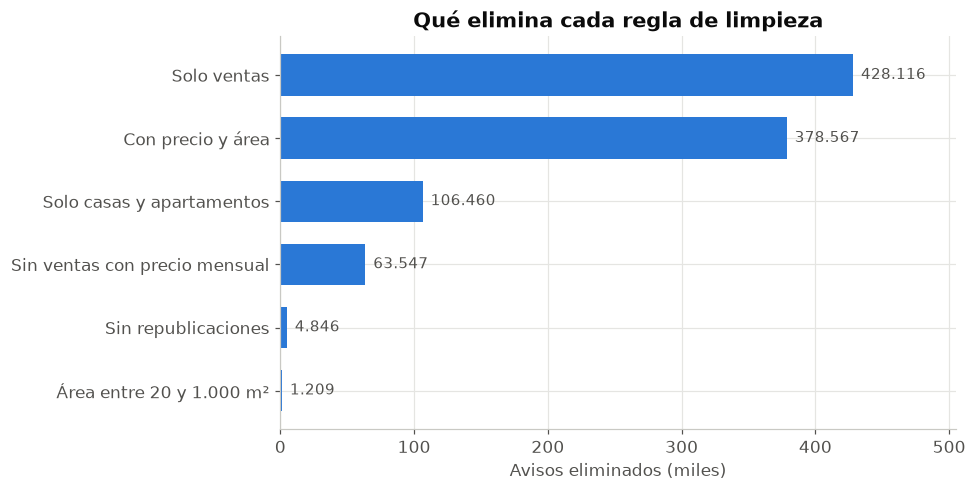

In [12]:
mayores = auditoria[auditoria["elimina"] > 0].nlargest(6, "elimina").sort_values("elimina")
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(mayores["regla"], mayores["elimina"] / 1000, color=AZUL, height=0.66)
for y, v in enumerate(mayores["elimina"].values):
    ax.text(v / 1000 + 6, y, f"{v:,.0f}".replace(",", "."), va="center", fontsize=9.5, color=SUAVE)
ax.set_xlim(0, mayores["elimina"].max() / 1000 * 1.18)
ax.set_xlabel("Avisos eliminados (miles)")
ax.set_title("Qué elimina cada regla de limpieza")
limpiar(ax); plt.tight_layout()
guardar(fig, "embudo_limpieza"); plt.show()

---
# 6. Análisis exploratorio

Cuatro hallazgos, cada uno con la gráfica que lo sustenta. La pregunta clave es: **¿qué nos dicen los datos?**

### Hallazgo 1 · La ciudad manda sobre el precio del metro cuadrado

> **Qué hace:** calcula el precio mediano del m² por ciudad (solo ciudades con al menos 100 avisos).
> **Por qué:** el precio por m² permite comparar viviendas de distinto tamaño. Se usa la **mediana**
> porque los promedios se distorsionan con los avisos caros.
> **Qué observar:** el m² en Bogotá cuesta varias veces lo que en las ciudades más baratas de la lista.

Precio mediano del m² (millones de pesos):
                 avisos    m2  precio
ciudad                               
Bogotá D.C         5238  5.42  550.00
Cartagena           362  4.58  500.00
Envigado            498  4.46  462.50
Medellín            986  4.12  480.00
Sabaneta            213  4.08  300.39
Itagui              105  3.55  240.00
Puerto Colombia     107  3.33  395.92
Chía                263  3.28  491.73


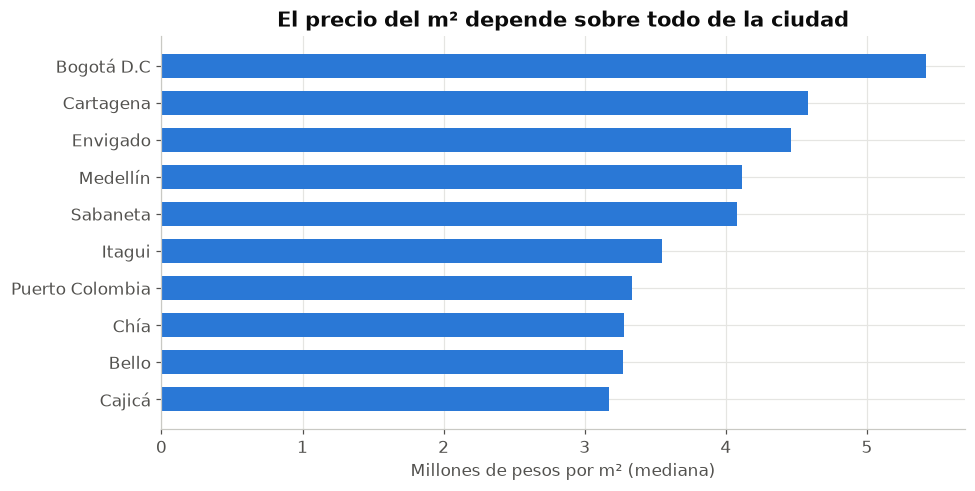

In [13]:
ciudades = (limpio[limpio["ciudad"] != "Sin dato"].groupby("ciudad")
            .agg(avisos=("price", "size"),
                 m2=("precio_m2", lambda s: s.median() / 1e6),
                 precio=("precio_millones", "median"))
            .query("avisos >= 100").sort_values("m2", ascending=False))
R["exploracion"] = {"ciudades": ciudades.head(8).round(2).reset_index().to_dict("records")}
print("Precio mediano del m² (millones de pesos):")
print(ciudades.head(8).round(2).to_string())

top = ciudades.head(10).sort_values("m2")
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(top.index, top["m2"], color=AZUL, height=0.65)
ax.set_xlabel("Millones de pesos por m² (mediana)")
ax.set_title("El precio del m² depende sobre todo de la ciudad")
limpiar(ax); plt.tight_layout()
guardar(fig, "hallazgo_ciudad"); plt.show()

### Hallazgo 2 · Dentro de una misma ciudad, la zona también cambia el precio

> **Qué hace:** repite el cálculo por zona, solo para Bogotá (la ciudad con más avisos).
> **Por qué:** comprobar si un promedio por ciudad esconde diferencias internas.
> **Qué observar:** la zona más cara de Bogotá cuesta **más del doble** que la más barata. Un precio único
> por ciudad ocultaría esa diferencia.

                    avisos    m2
zona                            
Zona Chapinero        1367  7.04
Zona Norte            1932  5.65
Zona Centro            117  5.49
Zona Noroccidental    1172  4.47
Zona Occidental        276  4.05
Zona Sur               142  3.12
Zona Suroccidental     232  3.11


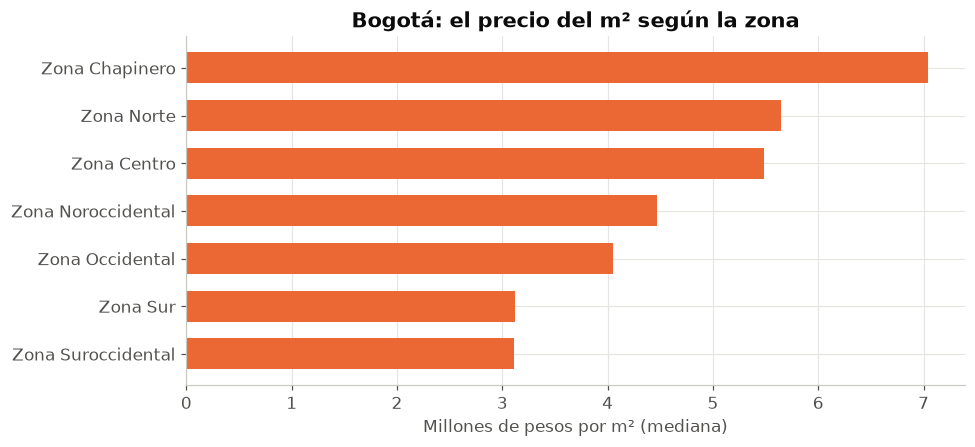

In [14]:
zonas = (limpio[(limpio["ciudad"] == "Bogotá D.C") & (limpio["zona"] != "Sin dato")].groupby("zona")
         .agg(avisos=("price", "size"), m2=("precio_m2", lambda s: s.median() / 1e6))
         .query("avisos >= 30").sort_values("m2"))
R["exploracion"]["zonas_bogota"] = zonas.round(2).reset_index().to_dict("records")
print(zonas.round(2).sort_values("m2", ascending=False).to_string())

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(zonas.index, zonas["m2"], color=NARANJA, height=0.65)
ax.set_xlabel("Millones de pesos por m² (mediana)")
ax.set_title("Bogotá: el precio del m² según la zona")
limpiar(ax); plt.tight_layout()
guardar(fig, "hallazgo_zonas"); plt.show()

### Hallazgo 3 · El área explica el precio, pero con mucha dispersión

> **Qué hace:** mide la correlación entre área y precio, y dibuja una muestra de 4.000 avisos. Luego repite
> la medición en el dataset de Medellín, que sí tiene el área completa.
> **Por qué:** comprobar que la relación que vemos no es un efecto de haber conservado solo los avisos que
> traen área.
> **Qué observar:** la nube sube de izquierda a derecha, pero está muy dispersa: **a igual área, el precio
> varía muchísimo**. Es decir, el área sola no alcanza para predecir.

Correlación con el precio (dataset principal):
area         0.692
bedrooms     0.286
bathrooms    0.625

Correlación área-precio en el dataset de Medellín (área completa): 0.842


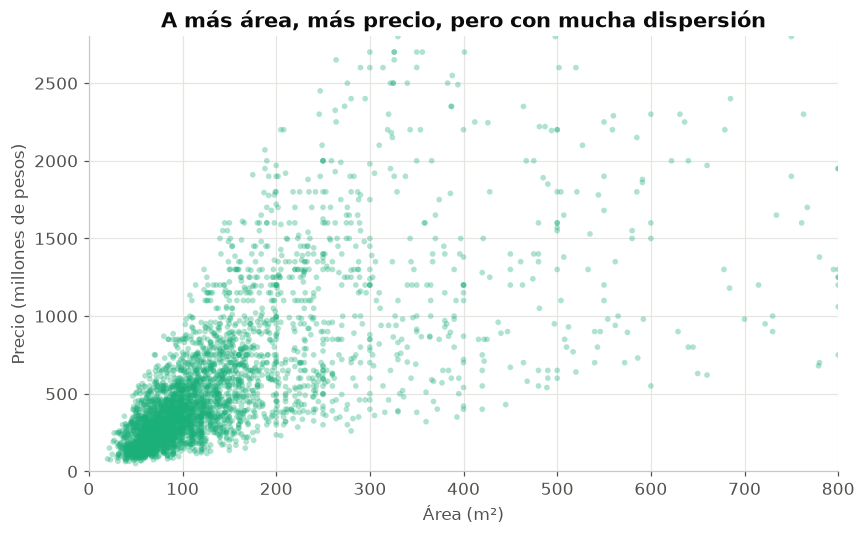

In [15]:
corr = limpio[["precio_millones", "area", "bedrooms", "bathrooms"]].corr()["precio_millones"].round(3)
dm_ok = dm[dm["area"].between(20, 1000) & dm["price"].between(30e6, 5e9)]
corr_medellin = round(dm_ok["area"].corr(dm_ok["price"]), 3)
R["exploracion"]["correlaciones"] = corr.to_dict()
R["exploracion"]["corr_medellin"] = corr_medellin
print("Correlación con el precio (dataset principal):")
print(corr.drop("precio_millones").to_string())
print(f"\nCorrelación área-precio en el dataset de Medellín (área completa): {corr_medellin}")

muestra = limpio.sample(4000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(muestra["area"], muestra["precio_millones"], s=14, alpha=0.35, color=VERDE, edgecolor="none")
ax.set_xlim(0, muestra["area"].quantile(0.99)); ax.set_ylim(0, muestra["precio_millones"].quantile(0.99))
ax.set_xlabel("Área (m²)"); ax.set_ylabel("Precio (millones de pesos)")
ax.set_title("A más área, más precio, pero con mucha dispersión")
limpiar(ax); plt.tight_layout()
guardar(fig, "hallazgo_area"); plt.show()

### Hallazgo 4 · El tiempo que tarda un aviso en salir varía mucho según la ciudad

> **Qué hace:** calcula cuántos días permanece publicado un aviso (fecha de baja menos fecha de
> publicación), solo para los avisos ya cerrados.
> **Por qué:** conecta con la causa «inmuebles que no rotan» del diagrama de Ishikawa de la Etapa 1.
> **Qué observar:** las ciudades tardan muy distinto. **Cuidado:** los avisos aún vigentes no tienen fecha
> de baja y quedan fuera, así que la cifra subestima la duración real.

Avisos aún vigentes (excluidos de esta medición): 21.8 %

Días publicado hasta que sale el aviso (mediana, avisos cerrados):
              cerrados   dias  lentos
ciudad                               
Cartagena          154  127.5    39.0
Sabaneta           121   41.0    18.2
Bogotá D.C        4839   34.0     5.0
Envigado           361   32.0     6.6
Medellín           547   30.0    13.0
Chía               231   30.0     1.7
Cali              2068   27.0     7.0
Bello              178   26.0     3.4
Barranquilla      1526   22.5     8.2
Pereira            149   15.0     0.0
Jamundí            218   13.5     5.0
Bucaramanga        239   10.0     3.3


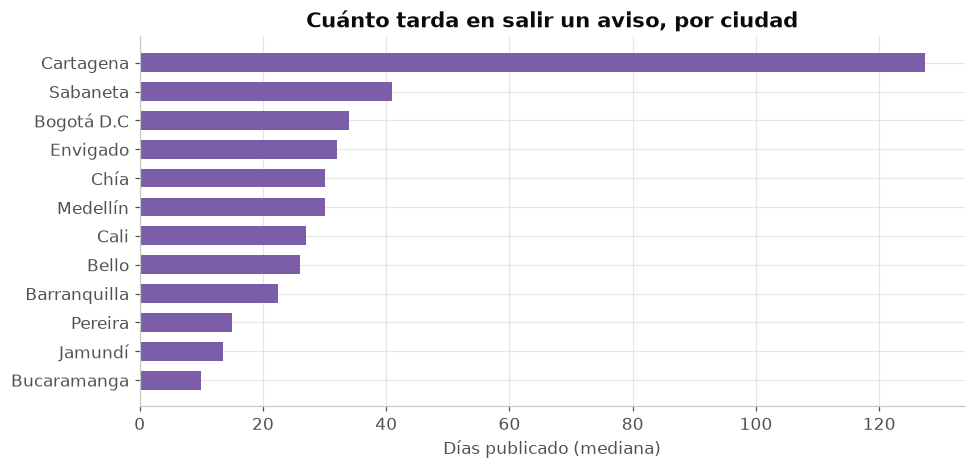

In [16]:
cerrados = limpio[(~limpio["esta_activo"]) & limpio["dias_publicado"].notna() & (limpio["dias_publicado"] >= 0)]
rotacion = (cerrados[cerrados["ciudad"] != "Sin dato"].groupby("ciudad")
            .agg(cerrados=("price", "size"), dias=("dias_publicado", "median"),
                 lentos=("dias_publicado", lambda s: (s > 180).mean() * 100))
            .query("cerrados >= 100").sort_values("dias", ascending=False))
R["exploracion"]["rotacion"] = rotacion.round(1).reset_index().to_dict("records")
R["exploracion"]["pct_vigentes"] = round(float(limpio["esta_activo"].mean() * 100), 1)
print(f"Avisos aún vigentes (excluidos de esta medición): {limpio['esta_activo'].mean() * 100:.1f} %\n")
print("Días publicado hasta que sale el aviso (mediana, avisos cerrados):")
print(rotacion.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4.4))
rot = rotacion.sort_values("dias")
ax.barh(rot.index, rot["dias"], color=MORADO, height=0.65)
ax.set_xlabel("Días publicado (mediana)")
ax.set_title("Cuánto tarda en salir un aviso, por ciudad")
limpiar(ax); plt.tight_layout()
guardar(fig, "hallazgo_rotacion"); plt.show()

---
# 7. Machine Learning supervisado: ¿cuánto vale una vivienda?

**Técnica: regresión.** Queremos predecir un número (el precio) a partir de las características del
inmueble. Es *supervisado* porque tenemos miles de avisos con su precio conocido para que el modelo aprenda.

```
Dataset limpio → Preparación → Train (80 %) → Modelo → Test (20 %) → Evaluación
```

### 7.1 Preparación y división en entrenamiento y prueba

> **Qué hace:** elige las variables de entrada, agrupa las ciudades poco frecuentes en «Otras» y separa
> los datos: 80 % para entrenar y 20 % para evaluar.
> **Por qué:** evaluar con los mismos datos con que se entrena engaña; el modelo podría «memorizar». Por eso
> se reserva un 20 % que **nunca ve** durante el entrenamiento. La semilla fija hace el resultado repetible.
> **Qué observar:** el tamaño de cada conjunto. Las variables de entrada son área, dormitorios, baños, tipo
> de inmueble y ciudad.
>
> **Decisión importante:** el segmento del K-Means (sección 8) **no** se usa como variable de entrada. Se
> calcula con el precio por m², así que usarlo para predecir el precio sería hacer trampa (*fuga de datos*).
> Tampoco usamos `dias_publicado`: solo se conoce cuando el aviso ya salió, y el modelo debe estimar el
> precio *al publicar*.

In [17]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_predict, train_test_split

# Ciudades: las 20 con más avisos se conservan; el resto se agrupa en «Otras»
principales = limpio["ciudad"].value_counts().head(20).index
limpio["ciudad_ml"] = limpio["ciudad"].where(limpio["ciudad"].isin(principales), "Otras").astype("category")

NUMERICAS = ["area", "bedrooms", "bathrooms", "es_casa"]
TODAS = NUMERICAS + ["ciudad_ml"]
X, y = limpio[TODAS], limpio["precio_millones"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Entrenamiento: {len(X_train):,} avisos      Prueba: {len(X_test):,} avisos")
R["division"] = {"entrenamiento": len(X_train), "prueba": len(X_test)}

Entrenamiento: 12,963 avisos      Prueba: 3,241 avisos


### 7.2 Entrenamiento y evaluación de los modelos

> **Qué hace:** entrena cuatro modelos, del más simple al más completo, y los evalúa con el 20 % de prueba.
> **Por qué:** comparar permite **justificar** la elección en lugar de presentar un solo número. El primero
> es una línea base: predice siempre la mediana. Si un modelo no la supera, no sirve.
> Gradient Boosting aprende sobre el *logaritmo* del precio, porque los precios son muy asimétricos y
> pocos avisos carísimos dominarían el error. La regresión lineal usa el precio directo, como en la
> Actividad 5 (con el logaritmo y el área sin transformar produciría predicciones exponenciales absurdas).
> **Qué observar:** cómo sube el R² al pasar de la línea base a la regresión lineal, luego a Gradient Boosting
> y finalmente al añadir la **ciudad**.
>
> **Métricas** (todas en millones de pesos salvo R² y MAPE):
> **R²** = qué parte de la variación del precio explica el modelo (1 = todo).
> **RMSE** = error típico, castiga más los errores grandes.
> **MAE** = error medio absoluto. **MAPE** = error medio como porcentaje del precio real.

In [18]:
def con_log(modelo):
    """El modelo aprende sobre log(precio) y devuelve la predicción en pesos."""
    return TransformedTargetRegressor(regressor=modelo, func=np.log1p, inverse_func=np.expm1)


MODELOS = {
    "Línea base (predice la mediana)": (DummyRegressor(strategy="median"), NUMERICAS),
    "Regresión lineal":                (LinearRegression(), NUMERICAS),
    "Gradient Boosting (sin ciudad)":  (con_log(HistGradientBoostingRegressor(random_state=42)), NUMERICAS),
    "Gradient Boosting (con ciudad)":  (con_log(HistGradientBoostingRegressor(random_state=42, categorical_features="from_dtype")), TODAS),
}

filas, ajustados = [], {}
for nombre, (modelo, columnas) in MODELOS.items():
    modelo.fit(X_train[columnas], y_train)
    pred = modelo.predict(X_test[columnas])
    filas.append({"modelo": nombre,
                  "R2": r2_score(y_test, pred),
                  "RMSE": root_mean_squared_error(y_test, pred),
                  "MAE": mean_absolute_error(y_test, pred),
                  "MAPE": float(np.mean(np.abs(pred - y_test) / y_test) * 100)})
    ajustados[nombre] = (modelo, columnas, pred)

metricas = pd.DataFrame(filas)
R["modelos"] = metricas.round(4).to_dict("records")
print(metricas.round({"R2": 4, "RMSE": 1, "MAE": 1, "MAPE": 1}).to_string(index=False))

negativas = int((ajustados["Regresión lineal"][2] < 0).sum())
R["lineal_negativas"] = negativas
print(f"\nLa regresión lineal predijo un precio NEGATIVO (imposible) en {negativas:,} de {len(y_test):,} avisos de prueba.")

                         modelo      R2  RMSE   MAE  MAPE
Línea base (predice la mediana) -0.1191 582.8 329.9  62.8
               Regresión lineal  0.5923 351.8 209.2  44.7
 Gradient Boosting (sin ciudad)  0.6675 317.7 176.6  31.7
 Gradient Boosting (con ciudad)  0.7891 253.0 133.7  22.4

La regresión lineal predijo un precio NEGATIVO (imposible) en 27 de 3,241 avisos de prueba.


> **Qué hace:** grafica la comparación de los cuatro modelos.
> **Por qué:** se entiende mejor de un vistazo. En verde el mejor.
> **Qué observar:** cada mejora es real y se ve. El salto de añadir la ciudad muestra que **la ubicación
> importa** tanto como las características físicas.

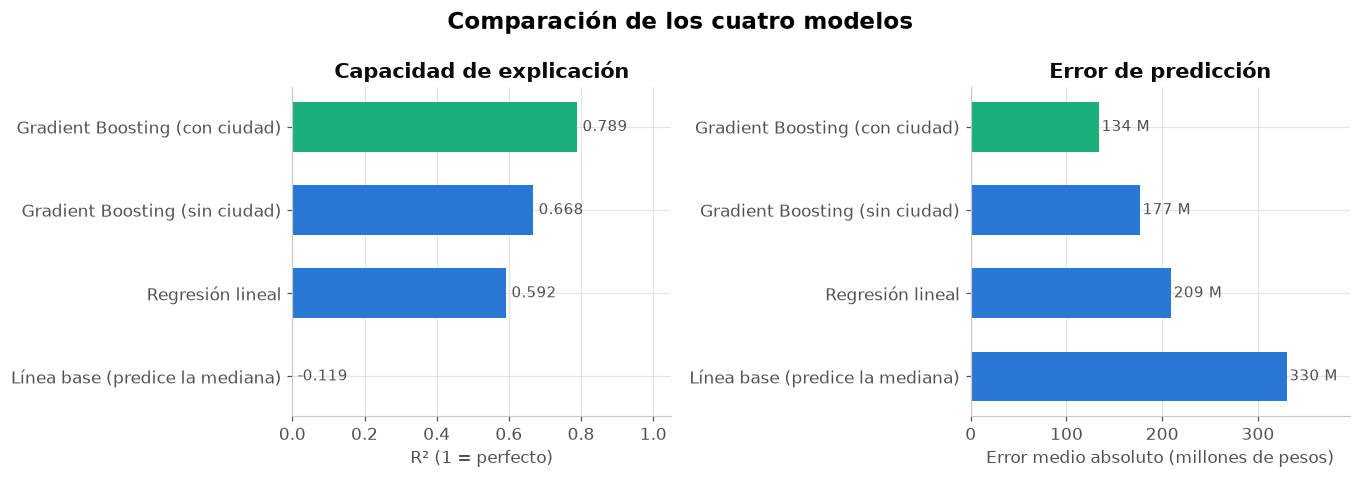

In [19]:
orden = metricas.sort_values("R2")
mejor_nombre = "Gradient Boosting (con ciudad)"
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

c1 = [VERDE if m == mejor_nombre else AZUL for m in orden["modelo"]]
a1.barh(orden["modelo"], orden["R2"].clip(lower=0), color=c1, height=0.6)
for y, v in enumerate(orden["R2"]):
    a1.text(max(v, 0) + 0.015, y, f"{v:.3f}", va="center", fontsize=10, color=SUAVE)
a1.set_xlim(0, 1.05); a1.set_xlabel("R² (1 = perfecto)"); a1.set_title("Capacidad de explicación")
limpiar(a1)

ord2 = metricas.sort_values("MAE", ascending=False)
c2 = [VERDE if m == mejor_nombre else AZUL for m in ord2["modelo"]]
a2.barh(ord2["modelo"], ord2["MAE"], color=c2, height=0.6)
for y, v in enumerate(ord2["MAE"]):
    a2.text(v + 3, y, f"{v:.0f} M", va="center", fontsize=10, color=SUAVE)
a2.set_xlim(0, ord2["MAE"].max() * 1.2); a2.set_xlabel("Error medio absoluto (millones de pesos)")
a2.set_title("Error de predicción")
limpiar(a2)

fig.suptitle("Comparación de los cuatro modelos", fontsize=15, weight="bold")
plt.tight_layout(); guardar(fig, "comparacion_modelos"); plt.show()

### 7.3 ¿Qué variables pesan más?

> **Qué hace:** mide la *importancia por permutación*: desordena una variable al azar y mira cuánto
> empeora el modelo. Si empeora mucho, esa variable era importante.
> **Por qué:** no basta con predecir; hay que **explicar** qué mueve el precio.
> **Qué observar:** el área es la variable más importante, y la ciudad va después. La caída puede superar
> 1 porque el R² puede volverse negativo: significa que sin esa variable el modelo queda peor que predecir
> siempre la mediana.

Caída del R² al desordenar cada variable (mayor = más importante):
Área                        1.153
Ciudad                      0.265
Baños                       0.137
Es casa (no apartamento)    0.051
Dormitorios                 0.023


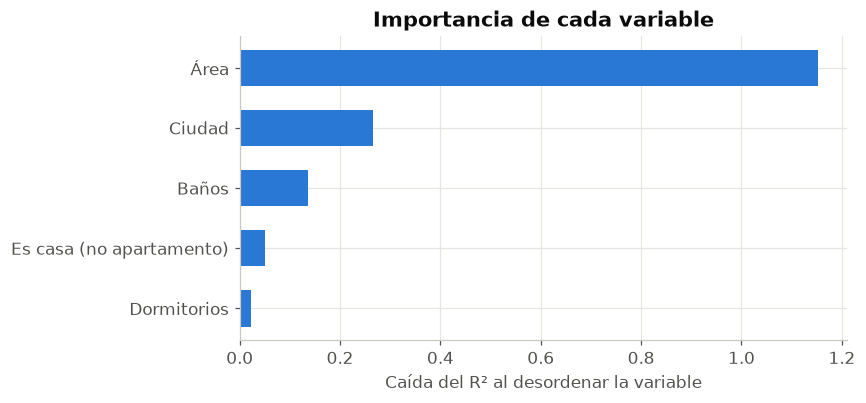

In [20]:
mejor, cols_mejor, pred_mejor = ajustados[mejor_nombre]
imp = permutation_importance(mejor, X_test[cols_mejor].iloc[:4000], y_test.iloc[:4000],
                             n_repeats=5, random_state=42, scoring="r2")
NOMBRES = {"area": "Área", "bedrooms": "Dormitorios", "bathrooms": "Baños",
           "es_casa": "Es casa (no apartamento)", "ciudad_ml": "Ciudad"}
importancia = (pd.Series(imp.importances_mean, index=[NOMBRES[c] for c in cols_mejor])
               .sort_values(ascending=False))
R["importancia"] = importancia.round(4).to_dict()
print("Caída del R² al desordenar cada variable (mayor = más importante):")
print(importancia.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(importancia.index[::-1], importancia.values[::-1], color=AZUL, height=0.6)
ax.set_xlabel("Caída del R² al desordenar la variable")
ax.set_title("Importancia de cada variable")
limpiar(ax); plt.tight_layout()
guardar(fig, "importancia_variables"); plt.show()

### 7.4 Predicho frente a real

> **Qué hace:** dibuja, para los avisos de prueba, el precio que predijo el modelo contra el precio real.
> **Por qué:** las métricas resumen; el gráfico muestra **dónde** acierta y dónde falla.
> **Qué observar:** los puntos cerca de la línea punteada son aciertos. Hay mucha más dispersión en los
> precios altos: ahí el modelo se equivoca más.

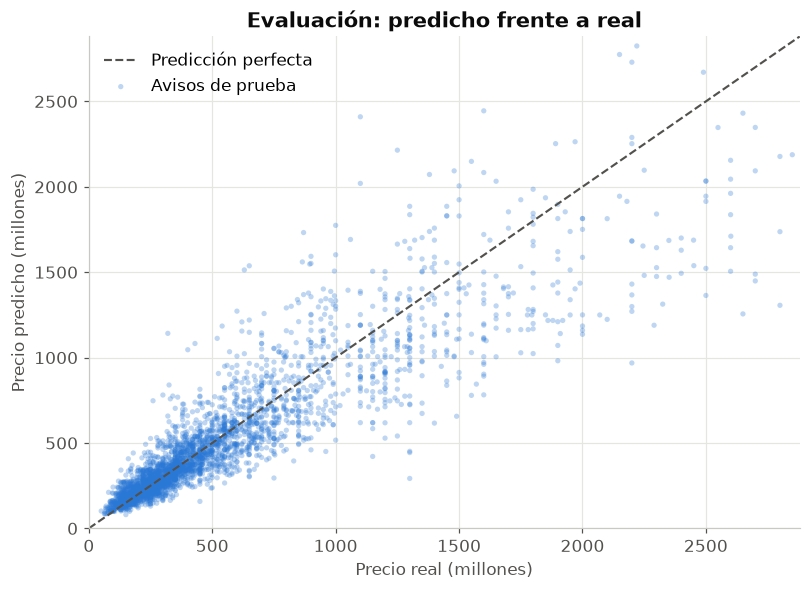

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
lim = [0, float(y_test.quantile(0.99))]
ax.plot(lim, lim, "--", color=SUAVE, linewidth=1.4, label="Predicción perfecta")
ax.scatter(y_test, pred_mejor, s=12, alpha=0.3, color=AZUL, edgecolor="none", label="Avisos de prueba")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Precio real (millones)"); ax.set_ylabel("Precio predicho (millones)")
ax.set_title("Evaluación: predicho frente a real")
ax.legend(frameon=False); limpiar(ax); plt.tight_layout()
guardar(fig, "predicho_vs_real"); plt.show()

---
# 8. Machine Learning no supervisado: ¿qué grupos de vivienda existen?

**Técnica: clustering (K-Means).** Aquí no hay una respuesta conocida: queremos que el algoritmo
**descubra** grupos de viviendas parecidas por sí solo. Por eso es *no supervisado*.

K-Means agrupa por *distancia*, así que antes hay que **estandarizar** las variables: el área va de 20 a
1.000 y los baños de 1 a 10; sin estandarizar, el área dominaría todo.

### 8.1 ¿Cuántos grupos? (método del codo y silueta)

> **Qué hace:** prueba de 2 a 8 grupos y mide dos cosas: la **inercia** (qué tan compactos son los grupos)
> y la **silueta** (qué tan separados están entre sí, de −1 a 1).
> **Por qué:** K-Means exige decidir de antemano cuántos grupos se quieren. Estas dos métricas ayudan.
> **Qué observar:** la silueta es más alta con k = 2 (0,41) y baja a cerca de 0,33 entre k = 3 y k = 5.
> Con k = 2 el algoritmo solo separa las viviendas grandes de las demás; con **k = 4** la separación es
> moderada, pero permite leer cuatro perfiles distintos. Elegimos k = 4 **por interpretabilidad de negocio**,
> no porque una métrica lo pida, y asumimos que la separación entre grupos es moderada.

 k  inercia  silueta
 2  43585.1   0.4084
 3  34130.3   0.3256
 4  28317.3   0.3255
 5  24636.1   0.3378
 6  21860.2   0.2983
 7  19804.8   0.2935
 8  17978.7   0.2798


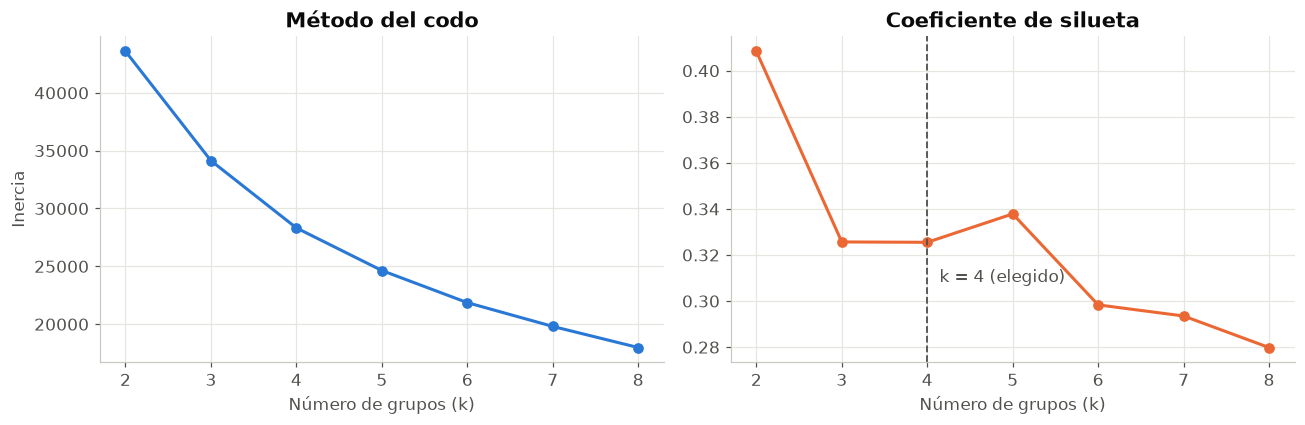

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

VARS_SEG = ["area", "precio_m2", "bedrooms", "bathrooms"]
Xs = StandardScaler().fit_transform(limpio[VARS_SEG])
rng = np.random.default_rng(42)
idx = rng.choice(len(Xs), size=min(5000, len(Xs)), replace=False)      # la silueta es lenta: se mide en una muestra

ks, inercias, siluetas = list(range(2, 9)), [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xs[idx], km.labels_[idx]))
R["seleccion_k"] = [{"k": k, "inercia": round(i, 1), "silueta": round(s, 4)} for k, i, s in zip(ks, inercias, siluetas)]
print(pd.DataFrame(R["seleccion_k"]).to_string(index=False))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(ks, inercias, marker="o", color=AZUL, linewidth=2); a1.set_title("Método del codo")
a1.set_xlabel("Número de grupos (k)"); a1.set_ylabel("Inercia")
a2.plot(ks, siluetas, marker="o", color=NARANJA, linewidth=2); a2.set_title("Coeficiente de silueta")
a2.axvline(4, color=SUAVE, linestyle="--", linewidth=1.2); a2.set_xlabel("Número de grupos (k)")
a2.annotate("k = 4 (elegido)", (4, siluetas[2]), xytext=(8, -26), textcoords="offset points", color=SUAVE)
for a in (a1, a2):
    a.set_xticks(ks); limpiar(a)
plt.tight_layout(); guardar(fig, "seleccion_k"); plt.show()

### 8.2 Los cuatro segmentos

> **Qué hace:** entrena K-Means con k = 4 y resume cómo es cada grupo (cuántos avisos, área, precio, etc.).
> Cada grupo se **nombra según su perfil**: el de mayor área, el de mayor precio por m², y los dos
> restantes según su precio.
> **Por qué:** un número de grupo no le dice nada al negocio; hay que traducirlo a un **perfil**. Además, un
> segmento puede ser caro por *tamaño* (propiedades grandes) o por *ubicación* (metro cuadrado costoso), y
> un nombre como «premium» mezclaría los dos casos.
> **Qué observar:** la columna `m2` (millones por m²) frente a `area`: las propiedades más grandes **no**
> son las de metro cuadrado más caro.

              segmento  avisos  % del total  area  precio  m2  dormitorios  banos
   Económicos estándar    8416         51.9  97.4   287.6 3.1          2.9    2.1
Compactos en zona cara    2614         16.1  76.0   483.2 6.2          1.7    1.9
Amplios de precio alto    3792         23.4 187.1   998.7 5.2          3.3    3.8
   Grandes propiedades    1382          8.5 472.4  1211.8 2.6          4.8    4.6


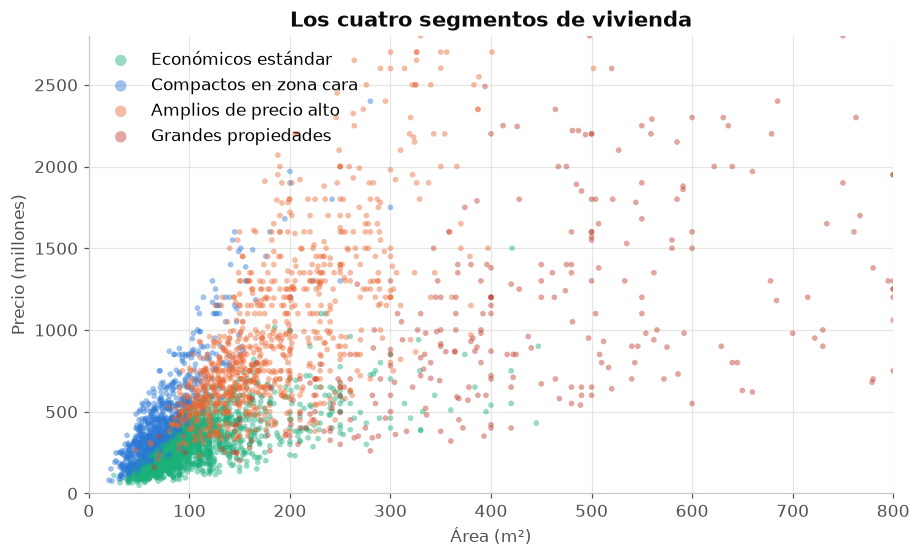

In [23]:
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xs)
limpio["grupo"] = km.labels_

perfil = (limpio.groupby("grupo")
          .agg(avisos=("price", "size"), area=("area", "mean"), precio=("precio_millones", "mean"),
               m2=("precio_m2", lambda s: s.mean() / 1e6), dormitorios=("bedrooms", "mean"),
               banos=("bathrooms", "mean"))
          .sort_values("precio"))

# El nombre depende del perfil, no del número de grupo (que es arbitrario)
grande = perfil["area"].idxmax()
resto = perfil.drop(grande)
compacto = resto["m2"].idxmax()
resto = resto.drop(compacto)
nombres = {grande: "Grandes propiedades", compacto: "Compactos en zona cara",
           resto["precio"].idxmin(): "Económicos estándar", resto["precio"].idxmax(): "Amplios de precio alto"}
perfil["segmento"] = perfil.index.map(nombres)
perfil["% del total"] = (perfil["avisos"] / len(limpio) * 100).round(1)
limpio["segmento"] = limpio["grupo"].map(perfil["segmento"])

R["segmentos"] = perfil.round(2).reset_index(drop=True).to_dict("records")
R["silueta_k4"] = round(float(silhouette_score(Xs[idx], km.labels_[idx])), 4)
print(perfil[["segmento", "avisos", "% del total", "area", "precio", "m2", "dormitorios", "banos"]]
      .round(1).to_string(index=False))

muestra = limpio.sample(4000, random_state=42)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for seg, color in zip(perfil["segmento"], [VERDE, AZUL, NARANJA, ROJO]):
    d = muestra[muestra["segmento"] == seg]
    ax.scatter(d["area"], d["precio_millones"], s=14, alpha=0.45, color=color, edgecolor="none", label=seg)
ax.set_xlim(0, muestra["area"].quantile(0.99)); ax.set_ylim(0, muestra["precio_millones"].quantile(0.99))
ax.set_xlabel("Área (m²)"); ax.set_ylabel("Precio (millones)")
ax.set_title("Los cuatro segmentos de vivienda"); ax.legend(frameon=False, markerscale=2, loc="upper left")
limpiar(ax); plt.tight_layout(); guardar(fig, "segmentos"); plt.show()

---
# 9. Resultados: dato → interpretación → decisión

Lo que distingue a *Business Analytics* de solo analizar datos es el último paso: **qué decisión habilita
cada resultado**.

### 9.1 Avisos con el precio muy lejos del valor estimado

> **Qué hace:** estima el precio de **todos** los avisos y marca los que están publicados más de un 15 %
> por debajo (posibles oportunidades) o por encima (posiblemente sobrevalorados) de ese valor.
> **Por qué:** es la tercera pregunta de negocio. Para no engañarnos, la estimación de cada aviso se hace
> con un modelo que **no lo vio entrenar** (validación cruzada de 5 partes): si no, el modelo «recordaría»
> los precios que ya conoce.
> **Qué observar:** la mayoría de los avisos está cerca de su valor estimado. Los marcados **no son
> oportunidades seguras**: son alertas que requieren revisión humana, porque parte de la diferencia es error
> del modelo.

In [24]:
# Predicción «fuera de muestra»: cada aviso se estima con un modelo que no lo vio entrenar
limpio["precio_estimado"] = cross_val_predict(con_log(HistGradientBoostingRegressor(random_state=42, categorical_features="from_dtype")),
                                              limpio[TODAS], limpio["precio_millones"], cv=5)
limpio["diferencia_pct"] = (limpio["precio_millones"] - limpio["precio_estimado"]) / limpio["precio_estimado"] * 100
limpio["estado_precio"] = np.select(
    [limpio["diferencia_pct"] < -15, limpio["diferencia_pct"] > 15],
    ["Por debajo del valor estimado", "Por encima del valor estimado"], default="Cerca del valor estimado")

conteo = limpio["estado_precio"].value_counts()
R["oportunidades"] = {
    "umbral_pct": 15,
    "por_debajo": int(conteo.get("Por debajo del valor estimado", 0)),
    "por_encima": int(conteo.get("Por encima del valor estimado", 0)),
    "cerca": int(conteo.get("Cerca del valor estimado", 0)),
}
print((conteo / len(limpio) * 100).round(1).astype(str).add(" %").to_string())

por_debajo = limpio[limpio["estado_precio"] == "Por debajo del valor estimado"]
print("\nLos cinco avisos más por debajo de su valor estimado (a revisar, no a comprar):")
print(por_debajo.nsmallest(5, "diferencia_pct")[["ciudad", "zona", "area", "bedrooms", "precio_millones",
                                               "precio_estimado", "diferencia_pct"]].round(1).to_string(index=False))

estado_precio
Cerca del valor estimado         44.2 %
Por encima del valor estimado    29.5 %
Por debajo del valor estimado    26.2 %

Los cinco avisos más por debajo de su valor estimado (a revisar, no a comprar):
    ciudad               zona  area  bedrooms  precio_millones  precio_estimado  diferencia_pct
Bogotá D.C     Zona Chapinero 750.0       2.0            720.0           2641.6           -72.7
Bogotá D.C Zona Suroccidental 391.0       6.0            380.0           1385.2           -72.6
Bogotá D.C           Zona Sur  38.0       2.0             39.9            139.9           -71.5
Bogotá D.C           Zona Sur  66.0       2.0             59.9            209.3           -71.4
      Cali           Sin dato 304.0       2.0            300.0           1015.2           -70.4


### 9.2 ¿Los avisos sobrevalorados tardan más en salir?

> **Qué hace:** compara cuántos días tardan en salir los avisos según su estado de precio.
> **Por qué:** es la hipótesis central del problema («precios subjetivos → inmuebles que no rotan»). Los
> datos permiten **comprobarla** en lugar de suponerla.
> **Qué observar:** si los sobrevalorados tardan más, la hipótesis se sostiene; si no, hay que decirlo.
> Solo entran avisos cerrados: los vigentes no tienen fecha de baja. Ojo: la fecha de baja indica que el
> aviso **dejó de publicarse**, no necesariamente que el inmueble se **vendió**.

In [25]:
cerrados = limpio[(~limpio["esta_activo"]) & (limpio["dias_publicado"] >= 0)]
rot = (cerrados.groupby("estado_precio")
       .agg(avisos=("price", "size"), dias_mediana=("dias_publicado", "median"),
            pct_mas_180=("dias_publicado", lambda s: (s > 180).mean() * 100)).round(1))
R["oportunidades"]["rotacion"] = rot.reset_index().to_dict("records")
print(rot.to_string())

med_sobre = rot.loc["Por encima del valor estimado", "dias_mediana"]
med_cerca = rot.loc["Cerca del valor estimado", "dias_mediana"]
sobre_mas_lentos = bool(med_sobre - med_cerca > 5)
R["oportunidades"]["sobrevalorados_mas_lentos"] = sobre_mas_lentos
print(f"\nLos avisos por encima del valor estimado {'SÍ' if sobre_mas_lentos else 'NO'} tardan más en salir "
      f"(mediana {med_sobre:.0f} días frente a {med_cerca:.0f}).")

                               avisos  dias_mediana  pct_mas_180
estado_precio                                                   
Cerca del valor estimado         5683          30.0          7.3
Por debajo del valor estimado    3366          29.5          8.8
Por encima del valor estimado    3627          29.0          7.2

Los avisos por encima del valor estimado NO tardan más en salir (mediana 29 días frente a 30).


### 9.3 Resumen de resultados

In [26]:
mejor_r2 = metricas.set_index("modelo").loc[mejor_nombre]
base_r2 = metricas.set_index("modelo").loc["Gradient Boosting (sin ciudad)"]
ciudad_top = ciudades.iloc[0]
zona_alta, zona_baja = zonas.iloc[-1], zonas.iloc[0]

resultados = pd.DataFrame([
    ("El área es la variable que más pesa; la ciudad va después",
     "El tamaño manda, pero la ubicación también",
     "Pedir siempre el área al publicar y tasar por ubicación"),
    (f"El m² en Bogotá cuesta {ciudad_top['m2']:.1f} M; en la zona más cara de Bogotá {zona_alta['m2']:.1f} M y en la más barata {zona_baja['m2']:.1f} M",
     "Un precio único por ciudad esconde diferencias enormes",
     "Tarifar y comparar por zona, no por ciudad"),
    (f"Añadir la ciudad sube el R² de {base_r2['R2']:.2f} a {mejor_r2['R2']:.2f}",
     "La ubicación aporta información que las características físicas no tienen",
     "Incluir siempre la ubicación en cualquier tasación"),
    (f"El modelo se equivoca en promedio {mejor_r2['MAE']:.0f} M ({mejor_r2['MAPE']:.0f} % del precio)",
     "Sirve como referencia, no como tasación exacta",
     "Usarlo para alertar precios fuera de rango, con revisión humana"),
    (f"{R['oportunidades']['por_debajo']:,} avisos están más de 15 % por debajo del valor estimado",
     "Mezcla de oportunidades reales y error del modelo",
     "Priorizarlos para revisión comercial"),
    (f"Existen 4 perfiles de vivienda: {', '.join(perfil['segmento'])}",
     f"Lo caro lo es por razones distintas: tamaño o ubicación (silueta {R['silueta_k4']:.2f}: separación moderada)",
     "Diferenciar captación y campañas por perfil"),
    (f"Los avisos por encima del valor estimado {'tardan más' if sobre_mas_lentos else 'NO tardan más'} en salir "
     f"(mediana {med_sobre:.0f} frente a {med_cerca:.0f} días)",
     "La hipótesis «precio alto = no rota» se sostiene" if sobre_mas_lentos else
     "La hipótesis «precio alto = no rota» NO se confirma con estos datos: el aviso mide cuánto se publica, no si se vendió",
     "Reforzar la revisión de precios" if sobre_mas_lentos else
     "No basar la política de precios solo en esa hipótesis; medir ventas reales"),
], columns=["Resultado", "Interpretación", "Decisión para el negocio"])
resultados

,Resultado,Interpretación,Decisión para el negocio
0,El área es la variable que más pesa; la ciudad va después,"El tamaño manda, pero la ubicación también",Pedir siempre el área al publicar y tasar por ubicación
1,El m² en Bogotá cuesta 5.4 M; en la zona más cara de Bogotá 7.0 M ...,Un precio único por ciudad esconde diferencias enormes,"Tarifar y comparar por zona, no por ciudad"
2,Añadir la ciudad sube el R² de 0.67 a 0.79,La ubicación aporta información que las características físicas no...,Incluir siempre la ubicación en cualquier tasación
3,El modelo se equivoca en promedio 134 M (22 % del precio),"Sirve como referencia, no como tasación exacta","Usarlo para alertar precios fuera de rango, con revisión humana"
4,"4,249 avisos están más de 15 % por debajo del valor estimado",Mezcla de oportunidades reales y error del modelo,Priorizarlos para revisión comercial
5,"Existen 4 perfiles de vivienda: Económicos estándar, Compactos en ...",Lo caro lo es por razones distintas: tamaño o ubicación (silueta 0...,Diferenciar captación y campañas por perfil
6,Los avisos por encima del valor estimado NO tardan más en salir (m...,La hipótesis «precio alto = no rota» NO se confirma con estos dato...,No basar la política de precios solo en esa hipótesis; medir venta...


---
# 10. Limitaciones del proyecto

> **Qué hace:** reúne las limitaciones **con sus cifras reales**, calculadas en este mismo notebook.
> **Por qué:** reconocer los límites es parte del análisis. Un resultado sin sus limitaciones puede inducir
> a decisiones equivocadas.
> **Qué observar:** la primera es la más grave: condiciona todas las demás.

In [27]:
a = R["calidad"]["area"]
limitaciones = [
    f"El ÁREA falta en el {a['sin_area_pct']:.1f} % de los avisos de venta de vivienda: el modelo se entrena con "
    f"{R['final']:,} de {R['dataset']['filas']:,} avisos ({R['final'] / R['dataset']['filas'] * 100:.1f} %).",
    "Los avisos registran el PRECIO PEDIDO, no el precio de cierre: se mide la oferta, no la transacción.",
    f"Datos de {R['dataset']['periodo'][0][:4]} y {R['dataset']['periodo'][1][:4]}: no reflejan los precios actuales.",
    f"El modelo solo usa área, dormitorios, baños, tipo de inmueble y ciudad. Con un error medio de "
    f"{mejor_r2['MAE']:.0f} M, no sustituye una tasación.",
    "La zona de la ciudad no entra al modelo: está vacía en la mayoría de los avisos.",
    f"El archivo tiene exactamente {R['dataset']['filas']:,} filas: parece un corte de exportación, "
    "así que no se puede asumir que contiene todos los avisos del periodo.",
    "Licencia «Unknown» en Kaggle: uso exclusivamente académico.",
    f"La medición de rotación excluye el {R['exploracion']['pct_vigentes']} % de avisos aún vigentes: subestima la duración real.",
    "Que un aviso deje de publicarse no significa que el inmueble se haya vendido: no tenemos las ventas reales.",
    f"La segmentación tiene una separación moderada (silueta {R['silueta_k4']:.2f}); la elección de 4 grupos es de negocio, no estadística.",
]
R["limitaciones"] = limitaciones
for i, texto in enumerate(limitaciones, 1):
    print(f"{i}. {texto}\n")

print("MEJORAS PROPUESTAS")
mejoras = [
    f"Recuperar el área desde el texto del aviso: {a['recuperable_texto']:,} avisos sin área la mencionan (falta validar la extracción).",
    "Añadir la zona, el estrato y la antigüedad, como en el dataset de Medellín.",
    "Usar datos actualizados y precios de cierre.",
    "Publicar el modelo como servicio para el portal inmobiliario.",
]
R["mejoras"] = mejoras
for m in mejoras:
    print(" -", m)

1. El ÁREA falta en el 94.4 % de los avisos de venta de vivienda: el modelo se entrena con 16,204 de 1,000,000 avisos (1.6 %).

2. Los avisos registran el PRECIO PEDIDO, no el precio de cierre: se mide la oferta, no la transacción.

3. Datos de 2020 y 2021: no reflejan los precios actuales.

4. El modelo solo usa área, dormitorios, baños, tipo de inmueble y ciudad. Con un error medio de 134 M, no sustituye una tasación.

5. La zona de la ciudad no entra al modelo: está vacía en la mayoría de los avisos.

6. El archivo tiene exactamente 1,000,000 filas: parece un corte de exportación, así que no se puede asumir que contiene todos los avisos del periodo.

7. Licencia «Unknown» en Kaggle: uso exclusivamente académico.

8. La medición de rotación excluye el 21.8 % de avisos aún vigentes: subestima la duración real.

9. Que un aviso deje de publicarse no significa que el inmueble se haya vendido: no tenemos las ventas reales.

10. La segmentación tiene una separación moderada (silueta 0.33)

---
# 11. Exportar los resultados

> **Qué hace:** guarda en `salida/` (a) el CSV limpio con segmentos y predicciones, listo para **Power BI**,
> y (b) el resumen con todas las cifras (`resumen.json`), del que sale la presentación.
> **Por qué:** así hay una sola fuente de verdad: lo que se ve en la presentación es exactamente lo que
> calculó este notebook. En Power BI: *Obtener datos → Texto o CSV → `salida/viviendas_powerbi.csv`*.
> **Qué observar:** los nombres de los archivos y su tamaño.

In [28]:
exportar = limpio[["id", "start_date", "ciudad", "zona", "property_type", "area", "bedrooms", "bathrooms",
                   "precio_millones", "precio_m2", "segmento", "precio_estimado", "diferencia_pct",
                   "estado_precio", "dias_publicado", "esta_activo"]].rename(columns={
    "start_date": "fecha_publicacion", "property_type": "tipo", "bedrooms": "dormitorios", "bathrooms": "banos"})
exportar.to_csv(SALIDA / "viviendas_powerbi.csv", index=False, encoding="utf-8-sig")

(SALIDA / "resumen.json").write_text(
    json.dumps(R, ensure_ascii=False, indent=1, default=lambda o: o.item() if hasattr(o, "item") else str(o)),
    encoding="utf-8")

for f in sorted(SALIDA.rglob("*")):
    if f.is_file():
        print(f"{str(f):<44}{f.stat().st_size / 1024:>9,.0f} KB")

salida\figuras\calidad_nulos.png                   60 KB
salida\figuras\comparacion_modelos.png             80 KB
salida\figuras\embudo_limpieza.png                 54 KB
salida\figuras\hallazgo_area.png                  175 KB
salida\figuras\hallazgo_ciudad.png                 40 KB
salida\figuras\hallazgo_rotacion.png               47 KB
salida\figuras\hallazgo_zonas.png                  41 KB
salida\figuras\importancia_variables.png           32 KB
salida\figuras\predicho_vs_real.png               161 KB
salida\figuras\segmentos.png                      220 KB
salida\figuras\seleccion_k.png                     79 KB
salida\resumen.json                                11 KB
salida\viviendas_powerbi.csv                    3,198 KB


---
### Fin

El notebook recorrió el ciclo completo:

**Problema → Necesidad → Pregunta de negocio → Datos → Data Quality → Data Cleaning → Exploración →
Machine Learning → Resultados → Limitaciones → Conclusiones.**